In [1]:
import torch
import torch.nn as nn
from torch import Tensor
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,SubsetRandomSampler,ConcatDataset
import torch.nn.functional as F

In [2]:
from helper import plot_map, from_upper_triu, upper_triangular_to_vector_skip_diagonals

In [3]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

from model import SeqNN

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(device)

cuda:0


In [5]:
# Load the entire model (architecture + weights)
model = torch.load("/home1/smaruj/pytorch_akita/model.pth")

/tmp/SLURM_276962/ipykernel_244006/3921338739.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("/home1/smaruj/pytorch_akita/model.pth")


In [6]:
model = model.to(device)

In [7]:
# Set the model to evaluation mode (important for inference)
model.eval()

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (re_lu): ReLU()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 96, kernel_size=(11,), stride=(1,), padding=(5,), bias=False)
    (batch_norm): BatchNorm1d(96, eps=0.001, momentum=0.9265, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(96, 96, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(96, eps=0.001, momentum=0.9265, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(96, 96, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(96, eps=0.001, momentum=0.9265, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size

In [8]:
from torchinfo import summary

summary(model, input_size=(2, 4, 1048576), col_names=["output_size", "num_params"])

Layer (type:depth-idx)                   Output Shape              Param #
SeqNN                                    [2, 5, 99681]             --
├─StochasticReverseComplement: 1-1       [2, 4, 1048576]           --
├─StochasticShift: 1-2                   [2, 4, 1048576]           --
├─ReLU: 1-3                              [2, 4, 1048576]           --
├─ConvBlock: 1-4                         [2, 96, 524288]           --
│    └─Conv1d: 2-1                       [2, 96, 1048576]          4,224
│    └─BatchNorm1d: 2-2                  [2, 96, 1048576]          192
│    └─MaxPool1d: 2-3                    [2, 96, 524288]           --
├─ConvTower: 1-5                         [2, 96, 512]              --
│    └─Sequential: 2-4                   [2, 96, 512]              --
│    │    └─ReLU: 3-1                    [2, 96, 524288]           --
│    │    └─Conv1d: 3-2                  [2, 96, 524288]           46,080
│    │    └─BatchNorm1d: 3-3             [2, 96, 524288]           192
│    │

In [9]:
X = torch.load("/scratch1/smaruj/ledidi_targets/fountain_background/X_0.pt", weights_only=True)

In [ ]:
X.shape

In [10]:
y_bar = torch.load("/scratch1/smaruj/ledidi_targets/constant_dot_background/modified_y_dot_100_275_0.7p.pt", weights_only=True)

In [11]:
# to ensure the local, forked ledidi is used
# not the one installed using pip

import sys
sys.path.insert(0, "/home1/smaruj/ledidi")  # Add the directory where "ledidi" is located
from ledidi import Ledidi

In [ ]:
X.shape, y_bar.shape

In [ ]:
X.device, y_bar.device

In [ ]:
# mask_vector = torch.ones((1048576), dtype=torch.bool)
# mask_vector[523288:525288] = 0 # +-1kb

In [12]:
start_index = 523264
end_index = 525312

In [13]:
seq_length = end_index - start_index

In [ ]:
# double checking that seq_length is equal slice_length
seq_length

In [14]:
wrapper = Ledidi(model, verbose=True, batch_size=1,
                 input_loss=torch.nn.L1Loss(reduction='sum'), 
                #  output_loss=torch.nn.MSELoss(),
                output_loss=torch.nn.L1Loss(reduction='sum'),
                 max_iter=3000,
                 early_stopping_iter=2000,
                 slice_length=seq_length, 
                 slice_index_0=100,
                 slice_index_1=275,
                 use_semifreddo=False,
                 saved_tmp_out="/scratch1/smaruj/ledidi_targets/constant_flame_background/tower_out.pt",
                 return_history=True
                 ).cuda()

Model in train mode: False
Gradients enabled for weights: True
Weights shape torch.Size([1, 4, 2048])
Gradients enabled for weights 1: True
Weights 1 shape torch.Size([1, 4, 2048])


In [15]:
slice_torch = X[:,:,start_index : end_index]

In [16]:
X_l_flank = X[:,:,start_index - 2048*2 : start_index]
X_r_flank = X[:,:,end_index : end_index + 2048*2]

In [ ]:
X_l_flank.shape, slice_torch.shape, X_r_flank.shape

In [ ]:
# x_bar, history = wrapper.fit_transform(X, modified_vector_tensor)
# if use_semifreddo=True
# x_bar = wrapper.fit_transform(slice_torch, y_bar, X_l_flank=X_l_flank, X_r_flank=X_r_flank)
# x_bar, history = wrapper.fit_transform(slice_torch, y_bar, X_l_flank=X_l_flank, X_r_flank=X_r_flank)

In [17]:
# if use_semifreddo=False
# x_bar = wrapper.fit_transform(X, y_bar, X_l_flank=X_l_flank, X_r_flank=X_r_flank)
x_bar, history = wrapper.fit_transform(X, y_bar, X_l_flank=X_l_flank, X_r_flank=X_r_flank)

iter=I	input_loss=0.0	output_loss=3.488e+05	total_loss=3.488e+05	time=0.0
iter=100	input_loss=725.0	output_loss=1.158e+05	total_loss=1.159e+05	time=4.654
iter=200	input_loss=792.0	output_loss=1.112e+05	total_loss=1.113e+05	time=4.518
iter=300	input_loss=852.0	output_loss=1.102e+05	total_loss=1.103e+05	time=4.549
iter=400	input_loss=933.0	output_loss=1.091e+05	total_loss=1.092e+05	time=4.587
iter=500	input_loss=991.0	output_loss=1.083e+05	total_loss=1.084e+05	time=4.525
iter=600	input_loss=1.034e+03	output_loss=1.083e+05	total_loss=1.084e+05	time=4.523
iter=700	input_loss=1.05e+03	output_loss=1.077e+05	total_loss=1.078e+05	time=4.527
iter=800	input_loss=1.07e+03	output_loss=1.073e+05	total_loss=1.074e+05	time=4.514
iter=900	input_loss=1.076e+03	output_loss=1.067e+05	total_loss=1.068e+05	time=4.494
iter=1000	input_loss=1.071e+03	output_loss=1.065e+05	total_loss=1.066e+05	time=4.532
iter=1100	input_loss=1.063e+03	output_loss=1.062e+05	total_loss=1.063e+05	time=4.538
iter=1200	input_loss=1

## Input and Output Loss Plots

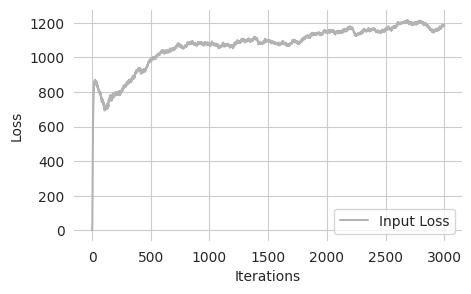

In [18]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('whitegrid')

plt.figure(figsize=(5, 3))
plt.plot(history['input_loss'], c='0.7', label="Input Loss")
plt.legend(fontsize=10)
plt.xlabel("Iterations")
plt.ylabel("Loss")

seaborn.despine(left=True, bottom=True)
plt.show()

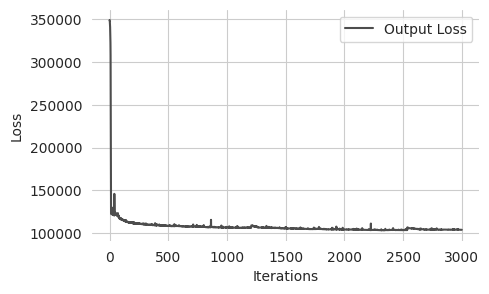

In [19]:
plt.figure(figsize=(5, 3))
plt.plot(history['output_loss'], c='0.3', label="Output Loss")
plt.legend(fontsize=10)
plt.xlabel("Iterations")
plt.ylabel("Loss")

seaborn.despine(left=True, bottom=True)
plt.show()

In [ ]:
# from ledidi.plot import plot_edits

# plot_edits(history)
# seaborn.despine(bottom=True, left=True)
# plt.show()

## Plotting edits

In [ ]:
X_new = X.clone()
X_new = X_new.repeat(10, 1, 1)

In [ ]:
X_new[:,:,start_index:end_index] = x_bar

In [ ]:
X_new = x_bar

In [ ]:
unique_set = set()

smallest_edited_location = 1048576
biggest_edited_location = 0

for i in range(1):

    print("sequence:", i)
    
    difference_vector = (X[0, :, :] == X_new[i, :, :]).all(dim=0).cpu().numpy()

    e=0
    edits_loc = []

    for loc_index in range(len(difference_vector)):
        if difference_vector[loc_index] == False:
            e += 1
            edits_loc.append(loc_index)
            if loc_index < smallest_edited_location:
                smallest_edited_location = loc_index
            if loc_index > biggest_edited_location:
                biggest_edited_location = loc_index
    
    edits_tuple = tuple(edits_loc)

    if edits_tuple not in unique_set:
        unique_set.add(edits_tuple)
    
    # print("number of edits:", e)
    # print("edits locations:", edits_loc)

In [ ]:
import numpy as np

In [ ]:
edits_array = np.array(edits_tuple) 
bins_array = edits_array // 2048

In [ ]:
bin_counts = np.bincount(bins_array)

In [ ]:
filtered_bins = np.arange(32, 480)
filtered_counts = bin_counts[filtered_bins]

In [ ]:
renumbered_bins = np.arange(0, 448)

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(renumbered_bins, filtered_counts, color='blue', alpha=0.5)
plt.xlabel("Bin Index (Renumbered 0-448)")
plt.ylabel("Count")
plt.title("Bin Counts (Ignoring First & Last 32 Bins)")
plt.show()

In [ ]:
len(unique_set)

In [ ]:
import seaborn as sns
import numpy as np

In [ ]:
X_numpy = X_new.detach().cpu().numpy()
X_chunk = X_numpy[:, :, smallest_edited_location:biggest_edited_location]  # Shape: (10, 4, 200)

# Convert one-hot encoding to integer labels (0=A, 1=T, 2=C, 3=G)
sequence_labels = np.argmax(X_chunk, axis=1)  # Shape: (10, 200)

# Define a color map for nucleotides
nucleotide_cmap = {
    0: "green",  # A
    1: "blue",     # C
    2: "yellow",    # G
    3: "red"    # T
}

# Create a custom colormap for visualization
cmap = [nucleotide_cmap[i] for i in range(4)]
sns.set(style="white")

# Plot heatmap of all sequences
plt.figure(figsize=(10, 3))
sns.heatmap(sequence_labels, cmap=cmap, cbar=False, xticklabels=False, yticklabels=False)
plt.xlabel("Position")
plt.ylabel("Sequence")
plt.title("One-Hot Encoded DNA Sequences")
plt.show()

## CTCF & CTCF-flanks PWM score

In [ ]:
# CTCF PWM
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

# CTCF with strong flanks (15bp)
CTCF_flanks = "/home1/smaruj/IterativeMutagenesis/PWM_with_flanks.npy"

In [ ]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [ ]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCFflanks = np.load(CTCF_flanks)

In [ ]:
def pwm_convolution(pwm, sequence):
    len_pwm, _ = pwm.shape
    len_seq, _ = sequence.shape
    conv_scores = []
    
    # Sliding window over the sequence matrix
    for i in range(len_seq - len_pwm + 1):
        # Extract submatrix (window) of the sequence of size len_pwm x 4
        window = sequence[i:i+len_pwm, :]
        
        # Compute the dot product (element-wise multiplication and sum) for the window
        score = np.sum(pwm * window)
        conv_scores.append(score)
    
    # Return the maximum convolution score
    return conv_scores


def reverse_complement_pwm(pwm):
    """Get the reverse complement of a given PWM."""
    # Reverse the rows (i.e., reverse the motif) and swap A<->T (0<->3) and C<->G (1<->2)
    rev_comp_pwm = pwm[::-1, :][:, [3, 2, 1, 0]]
    return rev_comp_pwm


In [ ]:
x_bar_np = x_bar[:, :, :].cpu().detach().numpy().transpose(0, 2, 1)

In [ ]:
308 * 2048

In [ ]:
# Compute PWM scores for the first sequence
CTCF_PWM_score = pwm_convolution(pwm_CTCF, x_bar_np[0, 270336:272384, :])  
rev_CTCF_PWM_score = pwm_convolution(reverse_complement_pwm(pwm_CTCF), x_bar_np[0, 270336:272384, :])  

# Create a figure
plt.figure(figsize=(10, 5))

# Plot forward PWM score with transparency
plt.plot(CTCF_PWM_score, label=">", alpha=0.6)  

# Plot reverse PWM score with transparency
plt.plot(rev_CTCF_PWM_score, label="<", alpha=0.6)  

plt.axhline(y=11.1, color='black', linestyle='--', linewidth=1, label="average strong CTCF")

# Labels and title
plt.xlabel("Position")
plt.ylabel("PWM Score")
plt.title("PWM Convolution Scores for Sequence 1, 1st slice")
plt.legend(loc="lower right")

# Show the plot
plt.show()


In [ ]:
# Compute PWM scores for the first sequence
CTCF_PWM_score = pwm_convolution(pwm_CTCF, x_bar_np[0, 628736:630784, :])  
rev_CTCF_PWM_score = pwm_convolution(reverse_complement_pwm(pwm_CTCF), x_bar_np[0, 628736:630784, :])  

# Create a figure
plt.figure(figsize=(10, 5))

# Plot forward PWM score with transparency
plt.plot(CTCF_PWM_score, label=">", alpha=0.6)  

# Plot reverse PWM score with transparency
plt.plot(rev_CTCF_PWM_score, label="<", alpha=0.6)  

plt.axhline(y=11.1, color='black', linestyle='--', linewidth=1, label="average strong CTCF")

# Labels and title
plt.xlabel("Position")
plt.ylabel("PWM Score")
plt.title("PWM Convolution Scores for Sequence 1, 2nd slice")
plt.legend(loc="lower right")

# Show the plot
plt.show()


In [ ]:
# Compute PWM scores for the first sequence
CTCF_PWM_score = pwm_convolution(pwm_CTCFflanks, x_bar_np[0, 270336:272384, :])  
rev_CTCF_PWM_score = pwm_convolution(reverse_complement_pwm(pwm_CTCFflanks), x_bar_np[0, 270336:272384, :])  

# Create a figure
plt.figure(figsize=(10, 5))

# Plot forward PWM score with transparency
plt.plot(CTCF_PWM_score, label=">", alpha=0.6)  

# Plot reverse PWM score with transparency
plt.plot(rev_CTCF_PWM_score, label="<", alpha=0.6)  

plt.axhline(y=21.5, color='black', linestyle='--', linewidth=1, label="average strong CTCF")

# Labels and title
plt.xlabel("Position")
plt.ylabel("PWM (flanks) Score")
plt.title("PWM Convolution Scores (CTCF+flanks) for Sequence 1")
plt.legend(loc="lower right")

# Show the plot
plt.show()

In [ ]:
# Compute PWM scores for the first sequence
CTCF_PWM_score = pwm_convolution(pwm_CTCFflanks, x_bar_np[0, 628736:630784, :])  
rev_CTCF_PWM_score = pwm_convolution(reverse_complement_pwm(pwm_CTCFflanks), x_bar_np[0, 628736:630784, :])  

# Create a figure
plt.figure(figsize=(10, 5))

# Plot forward PWM score with transparency
plt.plot(CTCF_PWM_score, label=">", alpha=0.6)  

# Plot reverse PWM score with transparency
plt.plot(rev_CTCF_PWM_score, label="<", alpha=0.6)  

plt.axhline(y=21.5, color='black', linestyle='--', linewidth=1, label="average strong CTCF")

# Labels and title
plt.xlabel("Position")
plt.ylabel("PWM (flanks) Score")
plt.title("PWM Convolution Scores (CTCF+flanks) for Sequence 1")
plt.legend(loc="lower right")

# Show the plot
plt.show()

## Predicted Maps

In [ ]:
model.eval()
with torch.no_grad():
    pred = model(X_new, training=False)

In [20]:
model.eval()
with torch.no_grad():
    pred = model(x_bar, training=False)

In [21]:
target_to_plot = 0

In [22]:
matrix_to_plot = from_upper_triu(pred[0, target_to_plot, :], matrix_len=448, num_diags=2)

In [ ]:
import numpy as np

In [ ]:
np.mean(matrix_to_plot[97:103,273:278])

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

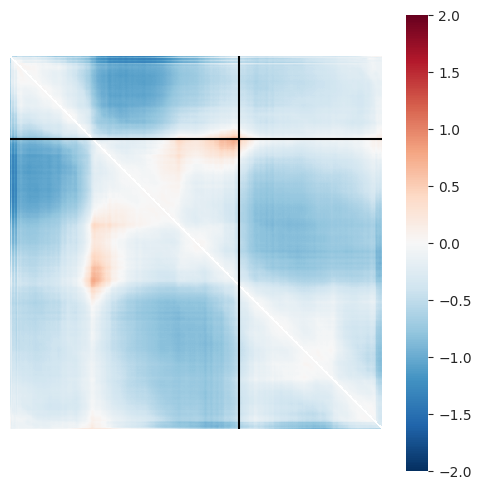

In [24]:
width=5
height=5
vmin = -2
vmax = 2
palette="RdBu_r"

fig, axes = plt.subplots(1, 1, figsize=(width, height))

sns.heatmap(
    matrix_to_plot,
    vmin=vmin,
    vmax=vmax,
    cbar=True,
    cmap=palette,
    square=True,
    xticklabels=False,
    yticklabels=False,
    ax=axes
)

# Highlight the 194th row
axes.hlines(y=100, xmin=0, xmax=448, colors='black', linewidth=1.5)

# Highlight the 254th column
axes.vlines(x=275, ymin=0, ymax=448, colors='black', linewidth=1.5)

plt.tight_layout()
plt.show()

In [ ]:
width=5
height=5
vmin = -2
vmax = 2
palette="RdBu_r"

fig, axes = plt.subplots(1, 1, figsize=(width, height))

sns.heatmap(
    matrix_to_plot,
    vmin=vmin,
    vmax=vmax,
    cbar=True,
    cmap=palette,
    square=True,
    xticklabels=False,
    yticklabels=False,
    ax=axes
)

# Highlight the 194th row
axes.hlines(y=100, xmin=0, xmax=448, colors='black', linewidth=1.5)

# Highlight the 254th column
axes.vlines(x=275, ymin=0, ymax=448, colors='black', linewidth=1.5)

plt.tight_layout()
plt.show()

In [ ]:
for i in range(1):
    print(i)
    plot_map(from_upper_triu(pred[i, target_to_plot, :], matrix_len=448, num_diags=2), vmin=-0.6, vmax=0.6, palette="RdBu_r", width=5, height=5)